In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('salesdaily.csv')
print(df.columns)
print(df.head())

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='str')
      datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0  1/2/2014    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1  1/3/2014    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2  1/4/2014    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3  1/5/2014    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4  1/6/2014    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  
0   248     Thursday  
1   276       Friday  
2   276     Saturday  
3   276       Sunday  
4   276       Monday  


In [3]:
# Put each drug into its own column
drugs = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

Total Sales:
 N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333


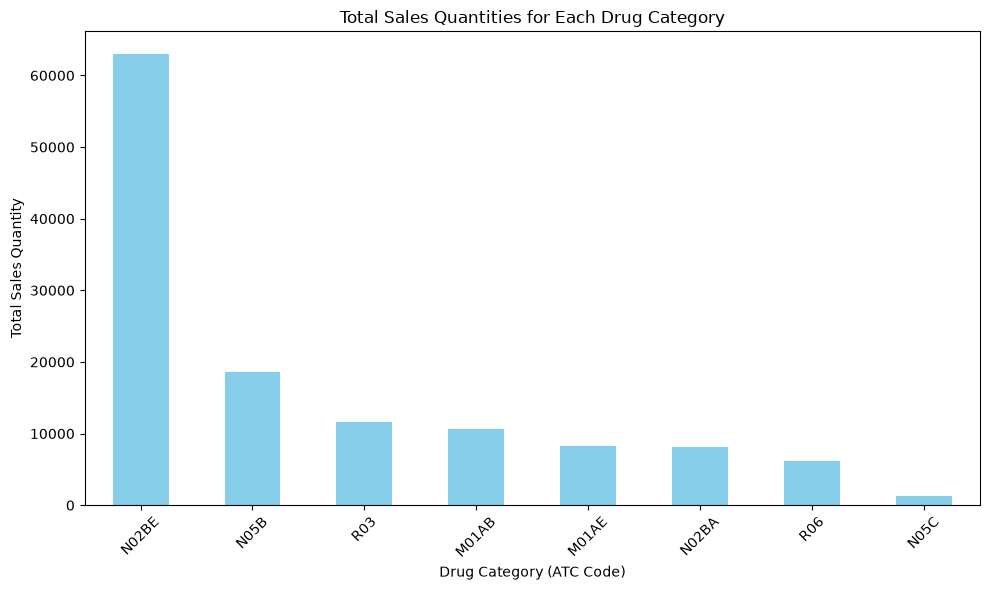

In [4]:
# 1. Total sales quantities for each drug category
total_sales = df[drugs].sum().sort_values(ascending=False)
print("Total Sales:\n", total_sales.to_string())

plt.figure(figsize=(10, 6))
total_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales Quantities for Each Drug Category')
plt.xlabel('Drug Category (ATC Code)')
plt.ylabel('Total Sales Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('total_sales.png')

In [5]:
# 2. Highest total sales per individual drug are shown with the code above. N02BE, N05B, R03.

In [6]:
# 3. Three drugs with the highest sales in January 2015, July 2016, September 2017.
jan_2015 = df[(df['Year'] == 2015) & (df['Month'] == 1)][drugs].sum().nlargest(3)
jul_2016 = df[(df['Year'] == 2016) & (df['Month'] == 7)][drugs].sum().nlargest(3)
sep_2017 = df[(df['Year'] == 2017) & (df['Month'] == 9)][drugs].sum().nlargest(3)

print("Jan 2015:\n", jan_2015.to_string())
print("Jul 2016:\n", jul_2016.to_string())
print("Sep 2017:\n", sep_2017.to_string())

Jan 2015:
 N02BE    1044.24
N05B      463.00
R03       177.25
Jul 2016:
 N02BE    652.362000
N05B     240.000000
M01AB    194.528333
Sep 2017:
 N02BE    863.75
N05B     223.00
R03      139.00


In [7]:
# 4. Which drug has sold the most often in 2017?
most_sold_2017 = df[df['Year'] == 2017][drugs].sum().idxmax()
print(f"4. Most sold drug category in 2017: {most_sold_2017}")

4. Most sold drug category in 2017: N02BE


In [8]:
# 5. Which drug category has the highest average daily sales?
avg_daily_sales = df[drugs].mean().sort_values(ascending=False)
print("5. Average Daily Sales:")
print(avg_daily_sales.round(2).to_string())

5. Average Daily Sales:
N02BE    29.92
N05B      8.85
R03       5.51
M01AB     5.03
M01AE     3.90
N02BA     3.88
R06       2.90
N05C      0.59


In [9]:
# 6. Are respiratory drugs (R03) sold more during specific months?
r03_monthly = df.groupby('Month')['R03'].mean()
print("6. Average Daily Sales of R03 by Month:")
print(r03_monthly.round(2).to_string())

6. Average Daily Sales of R03 by Month:
Month
1     6.84
2     6.90
3     6.29
4     5.77
5     5.01
6     4.35
7     2.96
8     3.10
9     4.40
10    7.21
11    6.23
12    7.92
